In [1]:
# Imports:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [3]:
# Define the function to be tested
def fcn(x, c):
    return 1/( 1 + c**2 * np.sum( x**2, axis=1 ))

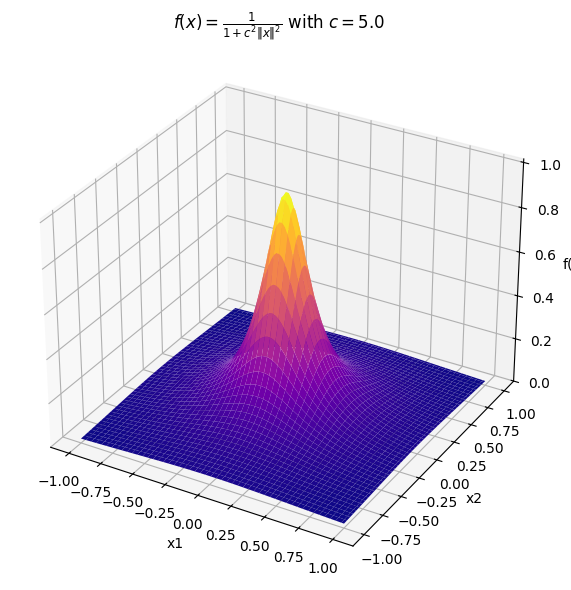

In [4]:
# Generate a grid in 2D
x1 = np.linspace(-1, 1, 100)
x2 = np.linspace(-1, 1, 100)
X1, X2 = np.meshgrid(x1, x2)
X_flat = np.c_[X1.ravel(), X2.ravel()]

# Define multiple values of c
c_values = [5.0]
Z_values = [fcn(X_flat, c).reshape(X1.shape) for c in c_values]

# Create 3D plots for each c
fig = plt.figure(figsize=(8, 6))
for i, (c, Z) in enumerate(zip(c_values, Z_values)):
    ax = fig.add_subplot(1, len(c_values), i+1, projection='3d')
    ax.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none')
    ax.set_title(rf'$f(x) = \frac{{1}}{{1 + c^2 \|x\|^2}}$' + f' with $c={c}$')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('f(x)')

plt.tight_layout()
plt.show()

In [5]:
# CP Decomposition of Chebyshev Interpolation Coefficients with Error Analysis

import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import parafac
import tensorly as tl

# Function to be interpolated
def fcn(x, c):
    return 1 / (1 + c**2 * np.sum(x**2, axis=1))

# Chebyshev polynomial generator
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Step 1: Generate coefficient matrix using QR
def generate_coeff_matrix(N, c):
    kx = np.arange(N+1)
    ky = np.arange(N+1)
    x_nodes = np.cos((2*kx + 1) * np.pi / (2*(N+1)))
    y_nodes = np.cos((2*ky + 1) * np.pi / (2*(N+1)))
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing="ij")

    coords = np.stack([X.ravel(), Y.ravel()], axis=1)
    F = fcn(coords, c).reshape((N+1, N+1))

    Tx = chebyshev_polys(x_nodes, N)
    Ty = chebyshev_polys(y_nodes, N)
    F_flat = F.T.ravel()
    A = np.kron(Ty.T, Tx.T)
    Q, R = np.linalg.qr(A)
    c_flat = np.linalg.solve(R, Q.T @ F_flat)
    return c_flat.reshape((N+1, N+1)), x_nodes, y_nodes

# Step 2: Function evaluator via CP-decomposed coefficient matrix
def evaluate_chebyshev_interp(CP_weights, A_factors, B_factors, N, resolution=100, c=5):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    Tx_eval = chebyshev_polys(xx, N)
    Ty_eval = chebyshev_polys(yy, N)

    # Build function approximation from CP
    Z_cp = np.zeros((resolution, resolution))
    for r in range(len(CP_weights)):
        Z_cp += CP_weights[r] * np.outer(
            Tx_eval.T @ A_factors[:, r],
            Ty_eval.T @ B_factors[:, r]
        )
    return Z_cp

# Step 3: Ground truth evaluator
def compute_exact_function_grid(fcn, c, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    coords = np.stack([XX.ravel(), YY.ravel()], axis=1)
    F = fcn(coords, c).reshape((resolution, resolution))
    return F

# Configs
N = 64
c = 5
resolution = 100

# TensorLy backend
tl.set_backend('numpy')

# Get coefficient matrix
C, x_nodes, y_nodes = generate_coeff_matrix(N, c)

In [6]:
# Evaluate the interpolant directly from the original coefficients
def evaluate_chebyshev_direct(C, x_eval, y_eval, N):
    Tx_eval = chebyshev_polys(x_eval, N)
    Ty_eval = chebyshev_polys(y_eval, N)
    return Tx_eval.T @ C @ Ty_eval

# Compute true function on the grid (already done earlier)
F_true = compute_exact_function_grid(fcn, c, resolution=resolution)

# Evaluate interpolation directly
xx = np.linspace(-1, 1, resolution)
yy = np.linspace(-1, 1, resolution)
F_interp = evaluate_chebyshev_direct(C, xx, yy, N)

# Compute baseline errors
diff_baseline = F_true - F_interp
rmse_baseline = np.sqrt(np.mean(diff_baseline**2))
maxe_baseline = np.max(np.abs(diff_baseline))

print(f"[Baseline] RMSE: {rmse_baseline:.2e}, MaxE: {maxe_baseline:.2e}")


[Baseline] RMSE: 3.67e-07, MaxE: 2.34e-06


Rank 1, RMSE: 2.66e-02, MaxE: 6.10e-02
Rank 2, RMSE: 4.39e-03, MaxE: 2.73e-02
Rank 3, RMSE: 7.64e-04, MaxE: 3.83e-03
Rank 4, RMSE: 1.25e-04, MaxE: 6.54e-04
Rank 5, RMSE: 1.98e-05, MaxE: 9.48e-05
Rank 6, RMSE: 3.12e-06, MaxE: 1.46e-05
Rank 7, RMSE: 6.09e-07, MaxE: 3.70e-06
Rank 8, RMSE: 3.75e-07, MaxE: 2.59e-06
Rank 9, RMSE: 3.67e-07, MaxE: 2.35e-06
Rank 10, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 11, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 12, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 13, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 14, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 15, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 16, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 17, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 18, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 19, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 20, RMSE: 3.67e-07, MaxE: 2.34e-06


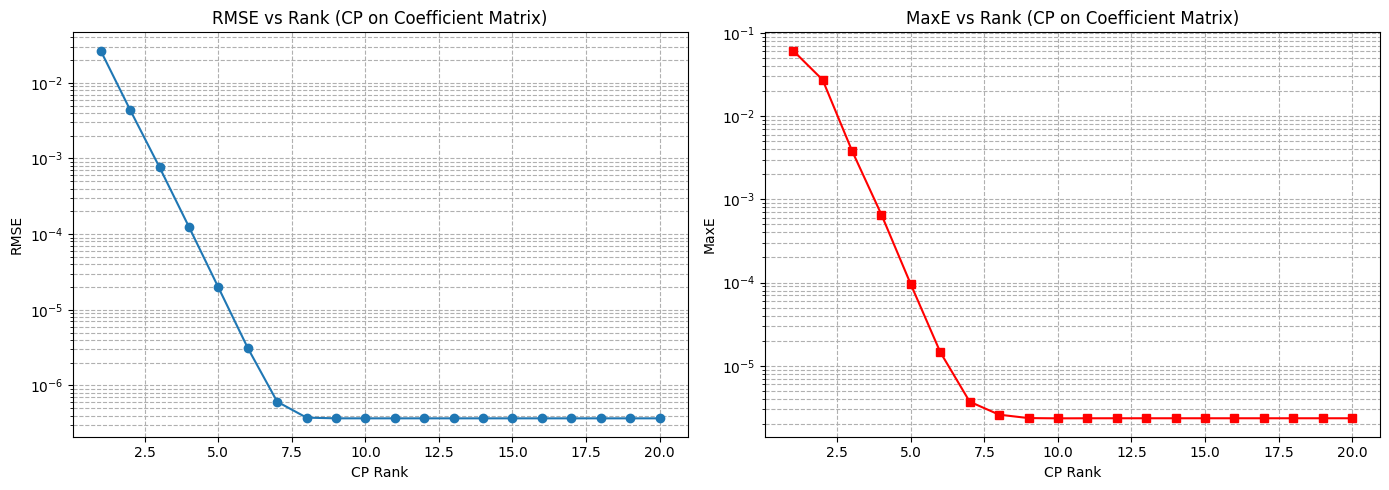

In [7]:
# CP decomposition of coefficient matrix
ranks = range(1, 21)
rmse_errors = []
maxe_errors = []

F_true = compute_exact_function_grid(fcn, c, resolution=resolution)

for rank in ranks:
    cp_tensor = parafac(C, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors
    A_factors, B_factors = factors  # shapes: (N+1, rank)

    # Evaluate interpolant using CP-decomposed coefficient matrix
    F_cp = evaluate_chebyshev_interp(weights, A_factors, B_factors, N, resolution, c)

    # Compute error with true function values
    diff = F_true - F_cp
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Step 4: Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Plot
axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_title("RMSE vs Rank (CP on Coefficient Matrix)")
axs[0].set_xlabel("CP Rank")
axs[0].set_ylabel("RMSE")
axs[0].set_yscale("log")
axs[0].grid(True, which='both', linestyle='--')

# MaxE Plot
axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_title("MaxE vs Rank (CP on Coefficient Matrix)")
axs[1].set_xlabel("CP Rank")
axs[1].set_ylabel("MaxE")
axs[1].set_yscale("log")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


In [16]:
from matplotlib import cm

# Choose the rank you want to visualize
rank = 10
cp_tensor = parafac(C, rank=rank, init='svd')
weights, (A_factors, B_factors) = cp_tensor

# Evaluate CP-based interpolation
F_cp = evaluate_chebyshev_interp(weights, A_factors, B_factors, N, resolution, c)

# Prepare meshgrid for visualization
xx = np.linspace(-1, 1, resolution)
yy = np.linspace(-1, 1, resolution)
X_vis, Y_vis = np.meshgrid(xx, yy, indexing="ij")
F_true = compute_exact_function_grid(fcn, c, resolution)

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_vis, Y_vis, F_true, cmap=cm.plasma, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_vis, Y_vis, F_cp, cmap=cm.plasma, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 129 is different from 65)

Rank 1, RMSE: 2.66e-02, MaxE: 6.10e-02
Rank 2, RMSE: 4.39e-03, MaxE: 2.73e-02
Rank 3, RMSE: 7.64e-04, MaxE: 3.83e-03
Rank 4, RMSE: 1.25e-04, MaxE: 6.54e-04
Rank 5, RMSE: 1.98e-05, MaxE: 9.48e-05
Rank 6, RMSE: 3.12e-06, MaxE: 1.46e-05
Rank 7, RMSE: 6.09e-07, MaxE: 3.70e-06
Rank 8, RMSE: 3.75e-07, MaxE: 2.59e-06
Rank 9, RMSE: 3.67e-07, MaxE: 2.35e-06
Rank 10, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 11, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 12, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 13, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 14, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 15, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 16, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 17, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 18, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 19, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 20, RMSE: 3.67e-07, MaxE: 2.34e-06


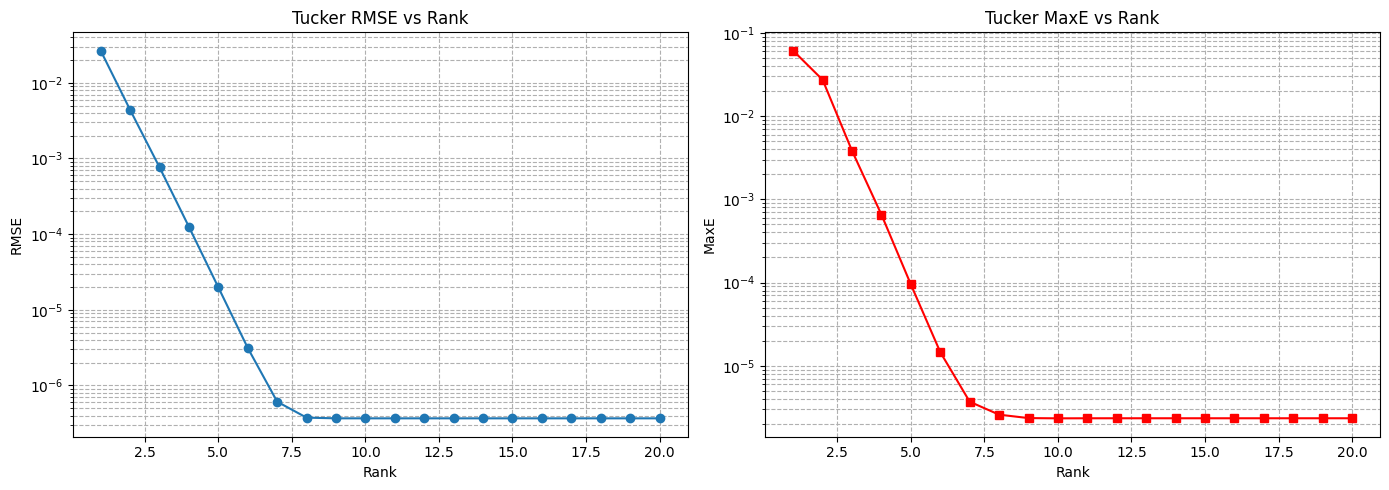

In [9]:
# Tucker Decomposition of Chebyshev Interpolation Coefficients with Error Analysis

import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import tucker
import tensorly as tl

# Function definition
def fcn(x, c):
    return 1 / (1 + c**2 * np.sum(x**2, axis=1))

# Chebyshev polynomial generator
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Generate coefficient matrix
def generate_coeff_matrix(N, c):
    kx = np.arange(N+1)
    ky = np.arange(N+1)
    x_nodes = np.cos((2*kx + 1) * np.pi / (2*(N+1)))
    y_nodes = np.cos((2*ky + 1) * np.pi / (2*(N+1)))
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing="ij")

    coords = np.stack([X.ravel(), Y.ravel()], axis=1)
    F = fcn(coords, c).reshape((N+1, N+1))

    Tx = chebyshev_polys(x_nodes, N)
    Ty = chebyshev_polys(y_nodes, N)
    F_flat = F.T.ravel()
    A = np.kron(Ty.T, Tx.T)
    Q, R = np.linalg.qr(A)
    c_flat = np.linalg.solve(R, Q.T @ F_flat)
    return c_flat.reshape((N+1, N+1)), x_nodes, y_nodes

# Evaluate interpolated function using Tucker-decomposed coefficient matrix
def evaluate_tucker_interp(core, A_factors, B_factors, N, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    Tx_eval = chebyshev_polys(xx, N)
    Ty_eval = chebyshev_polys(yy, N)

    Z_tucker = np.zeros((resolution, resolution))
    for i in range(core.shape[0]):
        for j in range(core.shape[1]):
            Z_tucker += core[i, j] * np.outer(
                Tx_eval.T @ A_factors[:, i],
                Ty_eval.T @ B_factors[:, j]
            )
    return Z_tucker

# Exact function values for comparison
def compute_exact_function_grid(fcn, c, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    coords = np.stack([XX.ravel(), YY.ravel()], axis=1)
    return fcn(coords, c).reshape((resolution, resolution))

# Parameters
N = 64
c = 5
resolution = 100
tl.set_backend('numpy')

# Build coefficient matrix
C, x_nodes, y_nodes = generate_coeff_matrix(N, c)

# Ranks to try
ranks = range(1, 21)
rmse_errors = []
maxe_errors = []

F_true = compute_exact_function_grid(fcn, c, resolution)

# Tucker decomposition loop
for rank in ranks:
    # Perform Tucker decomposition
    core, [A, B] = tucker(C, rank=[rank, rank])

    # Evaluate interpolated function from Tucker-decomposed coeffs
    F_tucker = evaluate_tucker_interp(core, A, B, N, resolution)

    # Compute error
    diff = F_true - F_tucker
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plot results
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_title("Tucker RMSE vs Rank")
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("RMSE")
axs[0].set_yscale("log")
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_title("Tucker MaxE vs Rank")
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("MaxE")
axs[1].set_yscale("log")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


In [10]:
# Configs
N = 128
c = 5
resolution = 100

# TensorLy backend
tl.set_backend('numpy')

# Get coefficient matrix
C, x_nodes, y_nodes = generate_coeff_matrix(N, c)

In [11]:
# Evaluate the interpolant directly from the original coefficients
def evaluate_chebyshev_direct(C, x_eval, y_eval, N):
    Tx_eval = chebyshev_polys(x_eval, N)
    Ty_eval = chebyshev_polys(y_eval, N)
    return Tx_eval.T @ C @ Ty_eval

# Compute true function on the grid (already done earlier)
F_true = compute_exact_function_grid(fcn, c, resolution=resolution)

# Evaluate interpolation directly
xx = np.linspace(-1, 1, resolution)
yy = np.linspace(-1, 1, resolution)
F_interp = evaluate_chebyshev_direct(C, xx, yy, N)

# Compute baseline errors
diff_baseline = F_true - F_interp
rmse_baseline = np.sqrt(np.mean(diff_baseline**2))
maxe_baseline = np.max(np.abs(diff_baseline))

print(f"[Baseline] RMSE: {rmse_baseline:.2e}, MaxE: {maxe_baseline:.2e}")


[Baseline] RMSE: 9.53e-13, MaxE: 6.94e-12


Rank 1, RMSE: 2.66e-02, MaxE: 6.10e-02
Rank 2, RMSE: 4.39e-03, MaxE: 2.73e-02
Rank 3, RMSE: 7.64e-04, MaxE: 3.83e-03
Rank 4, RMSE: 1.25e-04, MaxE: 6.54e-04
Rank 5, RMSE: 1.98e-05, MaxE: 9.50e-05
Rank 6, RMSE: 3.10e-06, MaxE: 1.44e-05
Rank 7, RMSE: 4.86e-07, MaxE: 2.42e-06
Rank 8, RMSE: 7.61e-08, MaxE: 3.18e-07
Rank 9, RMSE: 1.19e-08, MaxE: 5.75e-08
Rank 10, RMSE: 1.86e-09, MaxE: 9.64e-09
Rank 11, RMSE: 2.91e-10, MaxE: 1.36e-09
Rank 12, RMSE: 4.56e-11, MaxE: 1.95e-10
Rank 13, RMSE: 7.19e-12, MaxE: 2.61e-11
Rank 14, RMSE: 1.47e-12, MaxE: 9.29e-12
Rank 15, RMSE: 9.69e-13, MaxE: 6.83e-12
Rank 16, RMSE: 9.54e-13, MaxE: 6.95e-12
Rank 17, RMSE: 9.53e-13, MaxE: 6.95e-12
Rank 18, RMSE: 9.53e-13, MaxE: 6.94e-12
Rank 19, RMSE: 9.53e-13, MaxE: 6.94e-12
Rank 20, RMSE: 9.53e-13, MaxE: 6.94e-12


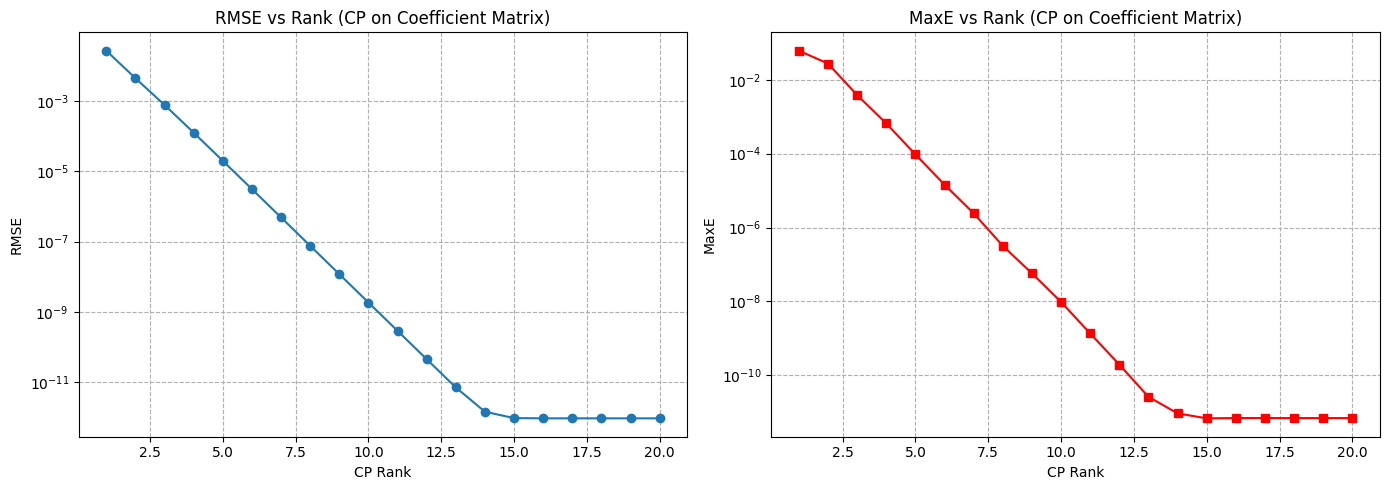

In [12]:
# CP decomposition of coefficient matrix
ranks = range(1, 21)
rmse_errors = []
maxe_errors = []

F_true = compute_exact_function_grid(fcn, c, resolution=resolution)

for rank in ranks:
    cp_tensor = parafac(C, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors
    A_factors, B_factors = factors  # shapes: (N+1, rank)

    # Evaluate interpolant using CP-decomposed coefficient matrix
    F_cp = evaluate_chebyshev_interp(weights, A_factors, B_factors, N, resolution, c)

    # Compute error with true function values
    diff = F_true - F_cp
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Step 4: Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Plot
axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_title("RMSE vs Rank (CP on Coefficient Matrix)")
axs[0].set_xlabel("CP Rank")
axs[0].set_ylabel("RMSE")
axs[0].set_yscale("log")
axs[0].grid(True, which='both', linestyle='--')

# MaxE Plot
axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_title("MaxE vs Rank (CP on Coefficient Matrix)")
axs[1].set_xlabel("CP Rank")
axs[1].set_ylabel("MaxE")
axs[1].set_yscale("log")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


In [13]:
# HIGHER DEGREE (WITH CHEBYSHEV NODES)

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander, chebval

# Define the function to be approximated
def f(x, y, c=5):
    return 1 / (1 + c**2 * (x**2 + y**2))

# Settings
N, M = 64, 64
d_x, d_y = 63, 63
R = 10  # CP rank
n_iter = 1000  # ALS iterations

# Generate Chebyshev nodes
x_nodes = np.cos(np.pi * np.arange(N) / (N - 1))
y_nodes = np.cos(np.pi * np.arange(M) / (M - 1))
X, Y = np.meshgrid(x_nodes, y_nodes, indexing='ij')
F = f(X, Y)

# Generate Chebyshev basis matrices
Tx = chebvander(x_nodes, d_x)
Ty = chebvander(y_nodes, d_y)

# Initialize coefficients randomly
A_coeffs = np.random.randn(d_x + 1, R)
B_coeffs = np.random.randn(d_y + 1, R)
lambdas = np.ones(R)

epsilon = 1e-8  # Regularization strength

for it in range(n_iter):
    A_eval = Tx @ A_coeffs
    B_eval = Ty @ B_coeffs
    F_hat = sum(lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r]) for r in range(R))

    # err = np.linalg.norm(F - F_hat) / np.linalg.norm(F)
    # Use RMSE for error reporting
    err = np.sqrt(np.mean((F - F_hat)**2))
    print(f"Iter {it+1}, RMSE: {err:.2e}")

    if np.isnan(err) or err > 1e5:
        print("Stopping due to divergence.")
        break

    # Update A_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Ty @ B_coeffs[:, r]
        rhs = Fr @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Tx.T @ Tx + epsilon * np.eye(Tx.shape[1])
        A_coeffs[:, r] = np.linalg.solve(lhs, Tx.T @ rhs)
        A_coeffs[:, r] /= np.linalg.norm(A_coeffs[:, r])

    # Update B_coeffs
    for r in range(R):
        Fr = F - sum(
            lambdas[k] * np.outer(Tx @ A_coeffs[:, k], Ty @ B_coeffs[:, k])
            for k in range(R) if k != r
        )
        Z = Tx @ A_coeffs[:, r]
        rhs = Fr.T @ Z
        if lambdas[r] != 0:
            rhs /= lambdas[r]
        lhs = Ty.T @ Ty + epsilon * np.eye(Ty.shape[1])
        B_coeffs[:, r] = np.linalg.solve(lhs, Ty.T @ rhs)
        B_coeffs[:, r] /= np.linalg.norm(B_coeffs[:, r])

    # Update lambdas with tighter clipping
    for r in range(R):
        A_r = Tx @ A_coeffs[:, r]
        B_r = Ty @ B_coeffs[:, r]
        num = np.sum(F * np.outer(A_r, B_r))
        denom = np.sum((np.outer(A_r, B_r))**2)
        lambdas[r] = num / denom if denom > 1e-12 else 0.0
        # print(lambdas[r])

    lambdas = np.clip(lambdas, 1e-3, 1e3)

Iter 1, RMSE: 1.05e+02
Iter 2, RMSE: 1.15e-01
Iter 3, RMSE: 9.35e-01
Iter 4, RMSE: 4.40e-01
Iter 5, RMSE: 2.11e-01
Iter 6, RMSE: 2.98e-01
Iter 7, RMSE: 1.18e-01
Iter 8, RMSE: 1.86e-01
Iter 9, RMSE: 1.10e-01
Iter 10, RMSE: 2.07e-01
Iter 11, RMSE: 9.14e-02
Iter 12, RMSE: 7.84e-02
Iter 13, RMSE: 5.91e-02
Iter 14, RMSE: 5.14e-02
Iter 15, RMSE: 5.84e-02
Iter 16, RMSE: 3.42e-02
Iter 17, RMSE: 2.74e-02
Iter 18, RMSE: 1.64e-02
Iter 19, RMSE: 5.75e-03
Iter 20, RMSE: 3.32e-02
Iter 21, RMSE: 2.51e-02
Iter 22, RMSE: 2.27e-02
Iter 23, RMSE: 2.70e-02
Iter 24, RMSE: 9.74e-03
Iter 25, RMSE: 4.88e-03
Iter 26, RMSE: 5.35e-02
Iter 27, RMSE: 9.12e-03
Iter 28, RMSE: 2.02e-02
Iter 29, RMSE: 3.41e-02
Iter 30, RMSE: 3.49e-02
Iter 31, RMSE: 2.08e-02
Iter 32, RMSE: 1.57e-01
Iter 33, RMSE: 1.73e-01
Iter 34, RMSE: 1.33e-01
Iter 35, RMSE: 5.28e-02
Iter 36, RMSE: 1.29e-01
Iter 37, RMSE: 7.29e-02
Iter 38, RMSE: 1.19e-01
Iter 39, RMSE: 4.24e-02
Iter 40, RMSE: 3.34e-02
Iter 41, RMSE: 1.03e-02
Iter 42, RMSE: 8.88e-03
I

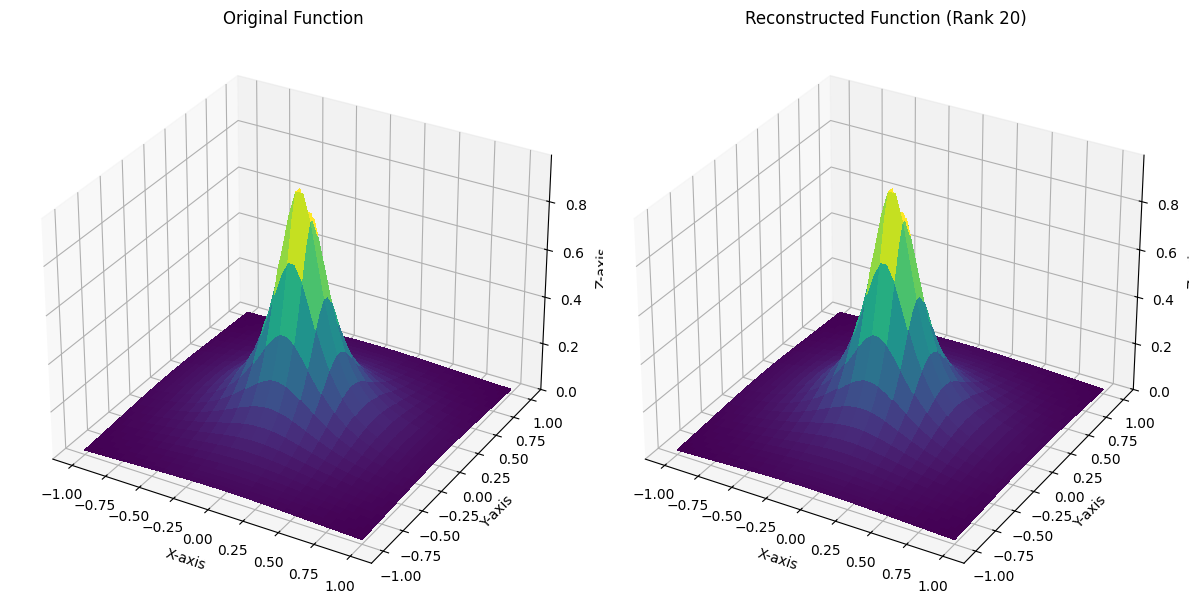

In [14]:
from matplotlib import cm

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_hat, cmap=cm.viridis, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()



Prediction RMSE: 3.19e-06
Prediction MaxE: 1.82e-05


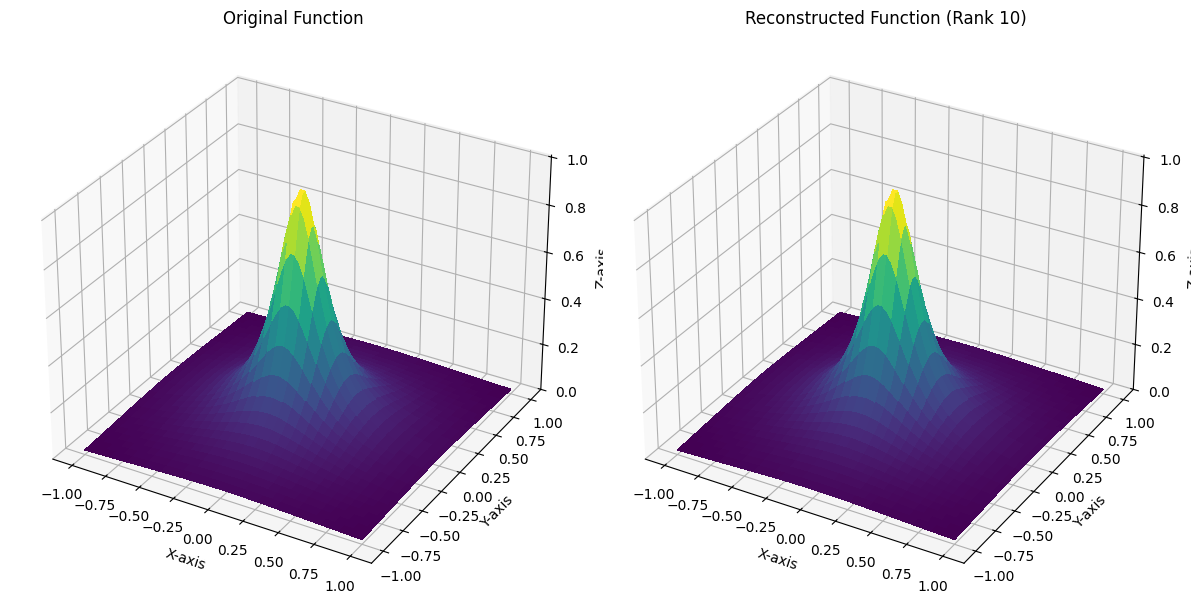

In [15]:
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

# --- Prediction on 2D grid ---
x = np.linspace(-1, 1, 64)
y = np.linspace(-1, 1, 64)
X, Y = np.meshgrid(x, y, indexing='ij')

Tx_rand = chebvander(x, d_x)      # shape: (64, d_x + 1)
Ty_rand = chebvander(y, d_y)      # shape: (64, d_y + 1)

A_eval = Tx_rand @ A_coeffs       # shape: (64, R)
B_eval = Ty_rand @ B_coeffs       # shape: (64, R)

# Compute prediction over the full grid
F_pred_grid = np.zeros((64, 64))
for r in range(R):
    F_pred_grid += lambdas[r] * np.outer(A_eval[:, r], B_eval[:, r])

F_true = f(X, Y)
rmse = np.sqrt(np.mean((F_true - F_pred_grid)**2))
maxe = np.max(np.abs(F_true - F_pred_grid))

print(f"\nPrediction RMSE: {rmse:.2e}")
print(f"Prediction MaxE: {maxe:.2e}")

# --- Plotting ---
fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F_true, cmap=cm.viridis, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_pred_grid, cmap=cm.viridis, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {R})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()
